# PR4 · Factor Models: What Really Drives a Stock

A factor model splits a stock's return into a part explained by broad market forces and a part that is specific to the company. It is the standard way to explain where risk and return come from.

## 1. Motivation

A fund manager reports 25% returns last year, while the market made 20%. Is the manager skilled? Or did they just hold riskier stocks that were bound to rise more in a rising market? The same question applies to every club strategy: is it finding something new, or quietly betting on the market? Factor models answer this by measuring how much of a return is **exposure** to common forces, and how much is left over as genuine **alpha**.

## 2. Intuition

Picture each stock as a boat on the sea. Part of its movement comes from the waves that lift all boats: the overall market, interest rates, the economy. The rest comes from the boat's own engine: company news, earnings, management.

A **factor** is one of those common waves. A stock's **beta** to a factor says how strongly it rides that wave. A beta of 1.5 to the market means it tends to move 1.5% when the market moves 1%.

Whatever the factors don't explain is **idiosyncratic** (company-specific) risk. As notebook 3 showed, that part diversifies away in a big portfolio. The factor part does not. So factor exposure is the risk that really matters for a portfolio.

## 3. The math

**CAPM regression** (one factor, the market). For stock $i$, with excess returns over the risk-free rate:
$$
R_{i,t} - r_{f,t} = \alpha_i + \beta_i\,(R_{m,t} - r_{f,t}) + \varepsilon_{i,t}.
$$
- $\beta_i$: exposure to the market. Estimated by ordinary least squares (OLS) as $\hat\beta_i = \operatorname{Cov}(R_i, R_m)/\operatorname{Var}(R_m)$.
- $\alpha_i$: average return *not* explained by market exposure. This is "alpha".
- $\varepsilon_{i,t}$: the idiosyncratic part, with mean zero.

**Risk decomposition.** Because $\varepsilon$ is uncorrelated with the market by construction,
$$
\sigma_i^2 = \underbrace{\beta_i^2\,\sigma_m^2}_{\text{systematic}} + \underbrace{\sigma_\varepsilon^2}_{\text{idiosyncratic}},
$$
and the regression $R^2$ is exactly the systematic share $\beta_i^2\sigma_m^2/\sigma_i^2$.

**Multi-factor model.** With $K$ factors $f_{1},\dots,f_{K}$:
$$
R_{i,t} - r_{f,t} = \alpha_i + \sum_{k=1}^{K}\beta_{i,k}\,f_{k,t} + \varepsilon_{i,t}.
$$
Academic models (Fama–French) use factors such as *value* (cheap minus expensive stocks) and *size* (small minus big). We build simple versions from our ETFs:
- **Market**: SPY minus the risk-free rate.
- **Size**: IWM (small caps) minus SPY (large caps).
- **Rates**: TLT (long Treasuries) minus the risk-free rate. Stocks that are hurt by rising rates will have a positive beta here.

**Is alpha real?** The regression gives $\hat\alpha$ and its standard error. The **t-statistic** $t = \hat\alpha / \text{SE}(\hat\alpha)$ tells us how many standard errors $\hat\alpha$ is from zero. As a rule of thumb, $|t| > 2$ is needed before taking an alpha seriously, and more if many stocks were tested (notebook 6).

## 4. Code it

### 4.1 Setup and factors

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)
meta = pd.read_csv("../data/meta.csv").set_index("ticker")

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})
pd.set_option("display.width", 120)

# Weekly returns: less noisy than daily, and avoids timing mismatches at the close
weekly = prices.drop(columns=["^VIX", "^IRX"]).resample("W-FRI").last().pct_change().dropna()
rf_weekly = (prices["^IRX"].resample("W-FRI").last() / 100 / 52).shift(1).reindex(weekly.index)

factors = pd.DataFrame({
    "Market": weekly["SPY"] - rf_weekly,     # market excess return
    "Size": weekly["IWM"] - weekly["SPY"],    # small minus big
    "Rates": weekly["TLT"] - rf_weekly,       # long bonds excess return
})
stocks = meta.index[meta.asset_type == "stock"]
excess = weekly[stocks].sub(rf_weekly, axis=0)    # R_i - r_f for every stock
factors.corr().round(2)

,Market,Size,Rates
Market,1.00,0.26,-0.22
Size,0.26,1.00,-0.12
Rates,-0.22,-0.12,1.00


The three factors are only mildly correlated with each other, so each one captures a different "wave". That matters for regression: strongly correlated factors make betas hard to separate.

### 4.2 CAPM for every stock

In [2]:
def capm(y, market):
    X = sm.add_constant(market)                  # adds the intercept alpha
    fit = sm.OLS(y, X).fit()
    return pd.Series({"alpha (ann.)": fit.params["const"] * 52,   # weekly alpha -> annual
                      "alpha t-stat": fit.tvalues["const"],
                      "beta": fit.params["Market"],
                      "R2": fit.rsquared})

capm_table = excess.apply(lambda y: capm(y, factors["Market"])).T
capm_table["sector"] = meta.loc[capm_table.index, "sector"]
print("Highest and lowest market betas:")
print(capm_table.sort_values("beta").iloc[[0, 1, 2, -3, -2, -1]].round(2))

Highest and lowest market betas:
      alpha (ann.)  alpha t-stat  beta    R2                  sector
DUK           0.04          0.89  0.44  0.15               Utilities
VZ            0.02          0.50  0.45  0.15  Communication Services
JNJ           0.05          1.41  0.48  0.23             Health Care
GS           -0.03         -0.53  1.30  0.53              Financials
BAC          -0.05         -0.88  1.34  0.46              Financials
NVDA          0.24          2.87  1.64  0.38  Information Technology


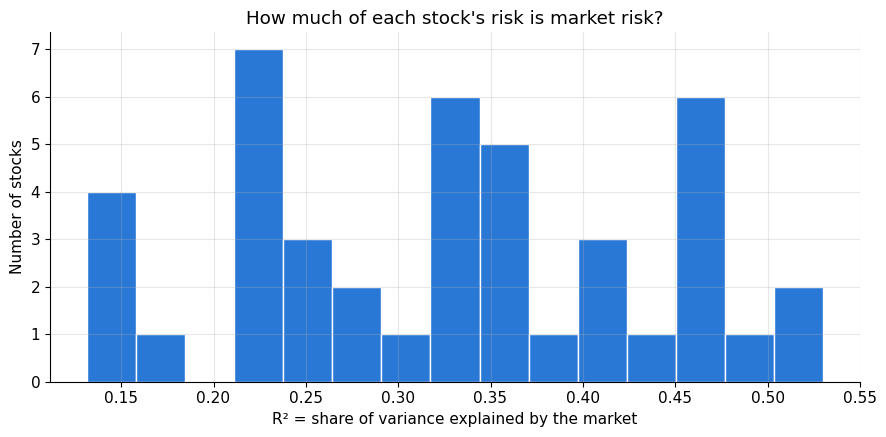

Median R-squared: 33%


In [3]:
fig, ax = plt.subplots()
ax.hist(capm_table["R2"], bins=15, color=COLORS[0], edgecolor="white")
ax.set_xlabel("R² = share of variance explained by the market")
ax.set_ylabel("Number of stocks")
ax.set_title("How much of each stock's risk is market risk?")
plt.tight_layout()
plt.show()
print(f"Median R-squared: {capm_table['R2'].median():.0%}")

- **Betas line up with intuition.** Utilities, telecoms and healthcare (DUK, VZ, JNJ) move less than half as much as the market. Banks (GS, BAC) and NVIDIA move 1.3–1.6 times as much.
- **The market explains only part of each stock.** The median R² is about one third. For a single stock, the company-specific part is the bigger one. That is exactly the part that cancels out when you hold many stocks (notebook 3).

### 4.3 Is there any alpha?

In [4]:
significant = capm_table[capm_table["alpha t-stat"].abs() > 2]
print(f"Stocks with |t| > 2: {len(significant)} of {len(capm_table)}")
print(significant[["alpha (ann.)", "alpha t-stat", "beta"]].round(2))
print(f"\nAverage alpha across all stocks: {capm_table['alpha (ann.)'].mean():.1%} per year")

Stocks with |t| > 2: 3 of 43
      alpha (ann.)  alpha t-stat  beta
AAPL          0.12          2.26  1.09
NVDA          0.24          2.87  1.64
COST          0.10          2.45  0.69

Average alpha across all stocks: 3.6% per year


Only 3 of 43 stocks have an alpha with $|t| > 2$: NVIDIA, Apple and Costco. With 43 tests, we would expect about 2 to clear that bar by chance alone (5% of 43). Also, all three are famous winners of the last 15 years, which is *why* they are in our dataset (survivorship, notebook 6). The average alpha of 3.6% a year across all stocks is the same survivorship tailwind. This doesn't mean these companies weren't great investments. It means that from this data alone we can't tell skill (or a real edge) apart from hindsight and luck.

### 4.4 Three factors

In [5]:
def multi_factor(y, F):
    fit = sm.OLS(y, sm.add_constant(F)).fit()
    out = fit.params.drop("const")
    out["R2"] = fit.rsquared
    return out

mf = excess.apply(lambda y: multi_factor(y, factors)).T
mf["R2 gain vs CAPM"] = mf["R2"] - capm_table["R2"]
by_sector = mf.groupby(meta.loc[mf.index, "sector"]).mean()
by_sector.sort_values("Rates").round(2)

,Market,Size,Rates,R2,R2 gain vs CAPM
sector,,,,,
Energy,0.80,0.48,-0.38,0.33,0.06
Financials,1.01,0.27,-0.29,0.54,0.05
Industrials,0.87,0.23,-0.09,0.38,0.02
Communication Services,0.95,-0.07,-0.03,0.29,0.01
Information Technology,1.21,-0.31,0.01,0.40,0.02
Health Care,0.65,-0.07,0.06,0.22,0.01
Consumer Staples,0.62,-0.21,0.13,0.29,0.03
Consumer Discretionary,0.98,0.04,0.14,0.38,0.01
Materials,0.89,0.18,0.15,0.38,0.02


The rates factor tells a clear economic story:

- **Utilities and real estate have large positive rates betas** (about 0.45). They behave partly like bonds: they gain when long-term rates fall (TLT up) and suffer when rates rise.
- **Financials and energy have negative rates betas.** Banks earn more when rates are higher, and both sectors tend to do well when the economy is strong and rates are rising.
- **The size factor separates sectors too:** energy and financials behave more like small caps; tech and staples more like mega-caps.

The extra factors add only a few points of R² on average. For utilities, though, they add 9 points: a single market beta misses a big part of their risk.

### 4.5 Betas change: a rolling view

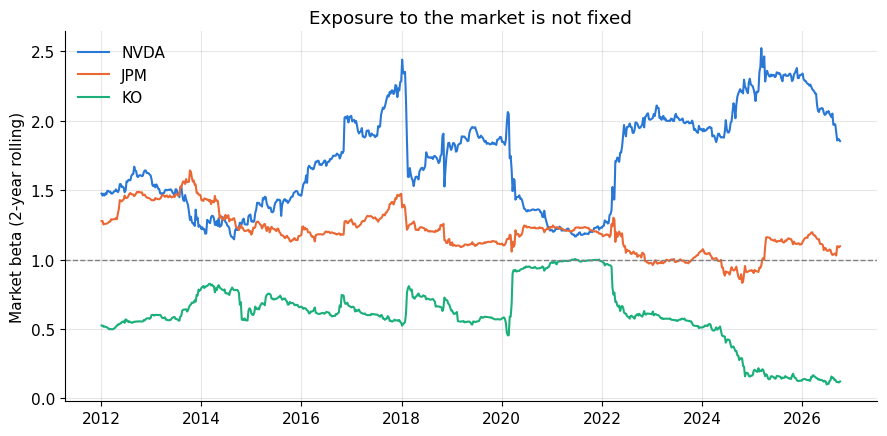

In [6]:
def rolling_beta(y, x, window=104):
    """Beta = Cov(y, x) / Var(x) over a rolling 2-year (104-week) window."""
    return y.rolling(window).cov(x) / x.rolling(window).var()

fig, ax = plt.subplots()
for t in ["NVDA", "JPM", "KO"]:
    ax.plot(rolling_beta(excess[t], factors["Market"]), label=t)
ax.axhline(1, color="grey", linewidth=1, ls="--")
ax.set_ylabel("Market beta (2-year rolling)")
ax.set_title("Exposure to the market is not fixed")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Betas move a lot. NVIDIA's market beta ranged from about 1.2 to 2.5 as it changed from a gaming-chip maker into the centre of the AI boom. Coca-Cola's beta fell from about 1.0 in 2020–2021 to below 0.2 recently. A beta estimated over one period is a rough guide to the next, not a constant.

## 5. Takeaways and where it breaks

- **For one stock, most risk is company-specific; for a portfolio, most risk is factor risk.** The market explains only about a third of a typical stock's variance. But the company-specific part diversifies away (notebook 3), so in a portfolio the betas matter more than the individual picks.
- **"Beating the market" needs a beta adjustment.** A high-beta portfolio *should* beat the market in a rising market. Only $\alpha$ measures skill, and it is rarely statistically significant.
- **Factors are tools, not truths.** Our ETF-based size and rates factors are crude. Proper factor data (market, size, value, momentum, profitability) for many countries is free from the Kenneth French Data Library.
- **Where it breaks:** betas drift over time, OLS estimates are noisy for short windows, and a linear model misses the fact that correlations rise in crashes (notebook 3).
- **This connects to the rest of the track:** a factor model gives a structured covariance matrix ($\Sigma = B\,\Sigma_f B^\top + D$), which is an even better shrinkage target than the identity in PR2.

**What you could build:** a factor "X-ray" for any portfolio the club runs: its market, size and rates betas, the share of risk that is systematic, and whether its alpha is statistically different from zero.